# Tacoma EV Adoption Analysis

This notebook explores electric vehicle adoption trends in Tacoma, Washington.
The goal is to analyze EV population data and prepare datasets for visualization
in a Tableau dashboard.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

print("Libraries loaded successfully")

In [ ]:

ev_data = pd.read_csv("../data/Electric_Vehicle_Population_Data_03_09_2026.csv")

len(ev_data)

In [ ]:
ev_data.info()

In [ ]:
ev_data.describe()

In [ ]:
ev_data["Electric Vehicle Type"].value_counts()

## Distribution of Electric Vehicle Types

This chart shows the distribution of Battery Electric Vehicles (BEV) and
Plug-in Hybrid Electric Vehicles (PHEV) in the dataset.

The dataset shows that BEVs dominate the EV registrations.

In [ ]:
tacoma_ev = ev_data[ev_data["City"] == "Tacoma"]
tacoma_ev.head()

In [ ]:
ev_data["Electric Vehicle Type"].value_counts().plot(kind="bar")

plt.title("Distribution of EV Types")
plt.xlabel("EV Type")
plt.ylabel("Number of Vehicles")

plt.show()

In [8]:
tacoma_ev = ev_data[ev_data["City"] == "Tacoma"]
top_makes = tacoma_ev["Make"].value_counts().head(10) 
print(top_makes)

Make
TESLA         2020
CHEVROLET      543
KIA            486
NISSAN         485
FORD           477
TOYOTA         295
HYUNDAI        235
BMW            199
VOLKSWAGEN     194
JEEP           131
Name: count, dtype: int64


*Distribution of Top 10 EV Makes in Tacoma*

In [ ]:
makes = top_makes.index
counts = top_makes.values

colors = cm.turbo(np.linspace(0, 1, len(makes)))

plt.figure(figsize=(10,6))
plt.barh(makes, counts, color=colors)
plt.xlabel("Number of Vehicles")
plt.ylabel("Make")
plt.title("Top 10 EV Makes in Tacoma")
plt.gca().invert_yaxis() 
plt.show()

In [ ]:
ev_type_counts = tacoma_ev["Electric Vehicle Type"].value_counts()
print(ev_type_counts)

*Distribution of EV Types in Tacoma*

In [ ]:
types = ev_type_counts.index
counts = ev_type_counts.values

colors = cm.jet(np.linspace(0, 1, len(types)))

plt.figure(figsize=(8,4))
plt.barh(types, counts, color=colors)
plt.xlabel("Number of Vehicles")
plt.ylabel("EV Type")
plt.title("EV Type Distribution in Tacoma")
plt.gca().invert_yaxis() 
plt.show()

In [ ]:
tacoma_range = tacoma_ev[~tacoma_ev["Electric Range"].isna()]["Electric Range"]
print(tacoma_range.describe())

*Electric Range Distribution of Tacoma EVs (Battery Only)*

In [ ]:
tacoma_range_nonzero = tacoma_range[tacoma_range > 0]

bins = 20
color = cm.turbo(np.linspace(0, 1, bins))

plt.figure(figsize=(10,6))
n, bins_edges, patches = plt.hist(tacoma_range_nonzero, bins=bins, edgecolor='black')

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.xlabel("Electric Range (miles)")
plt.ylabel("Number of Vehicles")
plt.title("Electric Range Distribution of Tacoma EVs (Battery Only)")
plt.show()

*EV Adoption in Tacoma by Model Year*

In [ ]:
ev_by_year = tacoma_ev["Model Year"].value_counts().sort_index()
print(ev_by_year.tail(15))

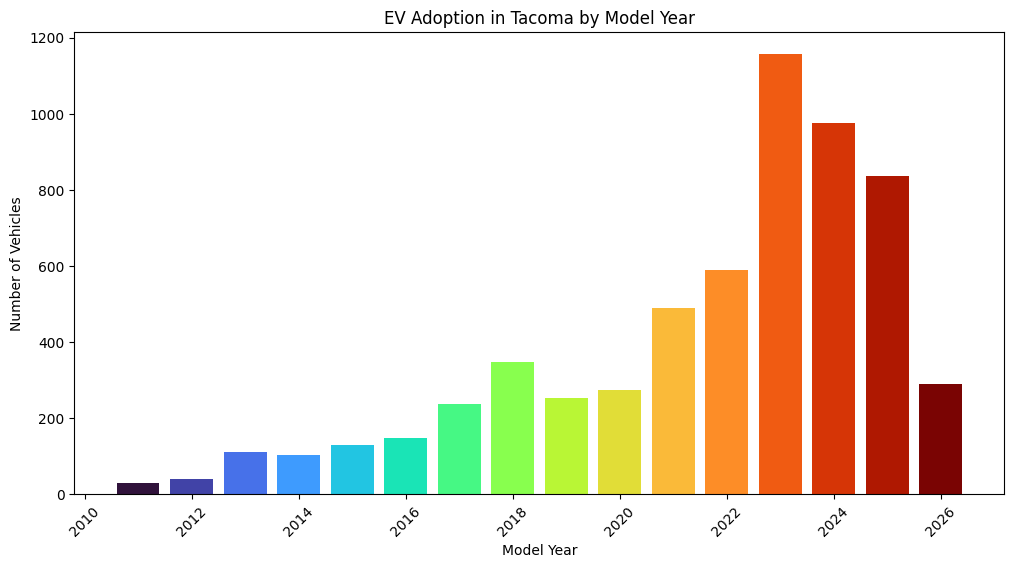

In [11]:
years = ev_by_year.index
counts = ev_by_year.values

colors = cm.turbo(np.linspace(0, 1, len(years)))

plt.figure(figsize=(12,6))
plt.bar(years, counts, color=colors)
plt.title("EV Adoption in Tacoma by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.xticks(rotation=45)
plt.show()